In [1]:
import os

import matplotlib.pyplot as plt

from run import Run
from visualizer import Visualizer

od = os.getcwd()

In [ ]:
%%script echo skipping
prog = 'erf2d9'

# xs = [2, 3, 4]
# xs = 2
# # ts = [1, 2, 4]
# ts = [2]
# # nxs = [10, 50, 80, 100, 500]#, 800, 1000, 5000]
# nxs = [10]
# # dts = [1e-1, 1e-2, 1e-3, 1e-4]
# dts = [1e-2]

args = {
	'xs': 2,
	'ts': 1,
	'nxs': [2, 4, 8],
	'dts': 0.0001,
	'tshift': 0.001,
	'tsteps': 100,
	
	'nthreads': os.cpu_count(),
	'dxdt': 'x',
	'interactive': True,
	'reference': 'run/reference',
	'dname': 'ref_test',

	'k1': 1.0,
	'k2': 0.25,
	'rho1': 1.0,
	'rho2': 2.0,
	'cp1': 1.0,
	'cp2': 0.25,
	'L': 1,
}


# run = Run(
# 	prog=prog,
# 	xs=xs,
# 	ts=ts,
# 	nxs=nxs,
# 	dts=dts,
# 	tsteps=tsteps,
# 	nthreads=nthreads,
# 	interactive=True,
# 	dxdt='x'
# )

run = Run(prog, **args)

In [ ]:
%%script echo skipping
print("Building required executables")
run.build()

In [ ]:
%%script echo skipping
os.chdir(run.wd)
print(f"Working in {run.wd}")

print(args['tsteps'])

run.run(**args)
# run.run_dt()

In [ ]:
os.chdir(f'{od}/runs/ref_test')
prog='erf2d9'

vis = Visualizer(prog, 'x', interactive=True, reference='runs/reference')
vis.prepare_pd()

# vis.plot_interface(vis.runs[0])

vis.plot_analysis('x')
# vis.plot_analysis('t')

Processing results in RESLT/2n10_1t0.0001
Processing results in RESLT/2n20_1t0.0001
Processing results in RESLT/2n100_1t0.0001
Processing results in RESLT/2n4_1t0.0001
Processing results in RESLT/2n50_1t0.0001
Processing results in RESLT/2n120_1t0.0001
Processing results in RESLT/2n6_1t0.0001
Processing results in RESLT/2n30_1t0.0001


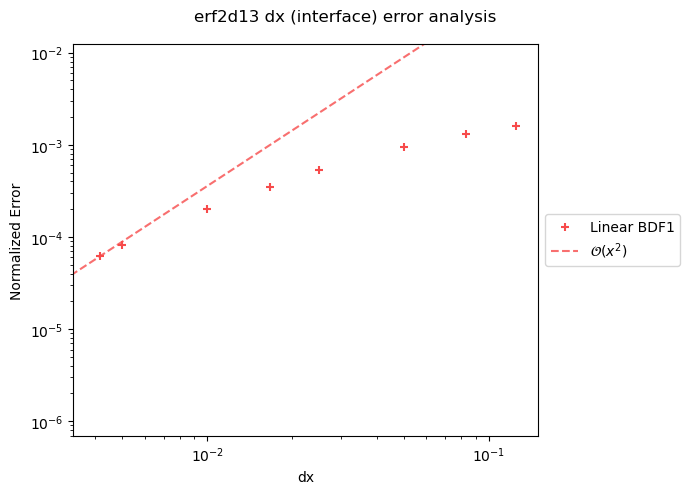

In [ ]:
os.chdir(f'{od}/runs/erf2d13_nytest')

os.chdir(f'./erf2d13_nytest_1')

vis1 = Visualizer('erf2d13', 'i', interactive=True, stylef='../pltstyle.mplstyle')
vis1.prepare_pd()
# vis1.plot_analysis('i')

Processing results in RESLT/2n10_1t0.0001
Processing results in RESLT/2n20_1t0.0001
Processing results in RESLT/2n100_1t0.0001
Processing results in RESLT/2n4_1t0.0001
Processing results in RESLT/2n50_1t0.0001
Processing results in RESLT/2n120_1t0.0001
Processing results in RESLT/2n6_1t0.0001
Processing results in RESLT/2n30_1t0.0001


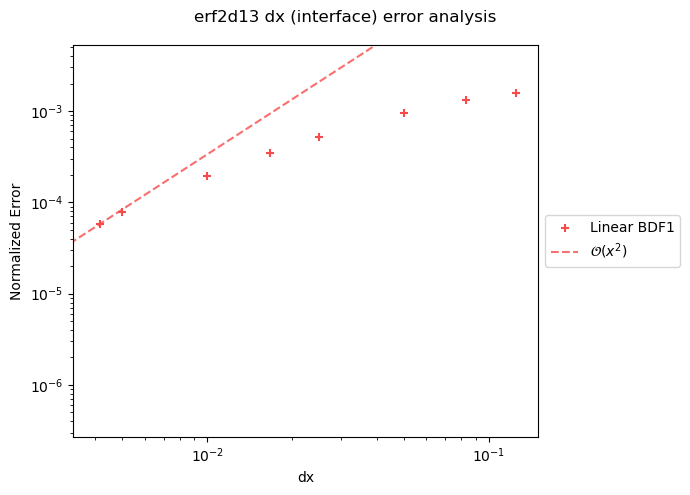

In [ ]:
os.chdir(f'{od}/runs/erf2d13_nytest')

os.chdir(f'./erf2d13_nytest_10')

vis10 = Visualizer('erf2d13', 'i', interactive=True, stylef='../pltstyle.mplstyle')
vis10.prepare_pd()
# vis10.plot_analysis('i')

Text(0.5, 0.98, 'erf2d13 dx error (interface)')

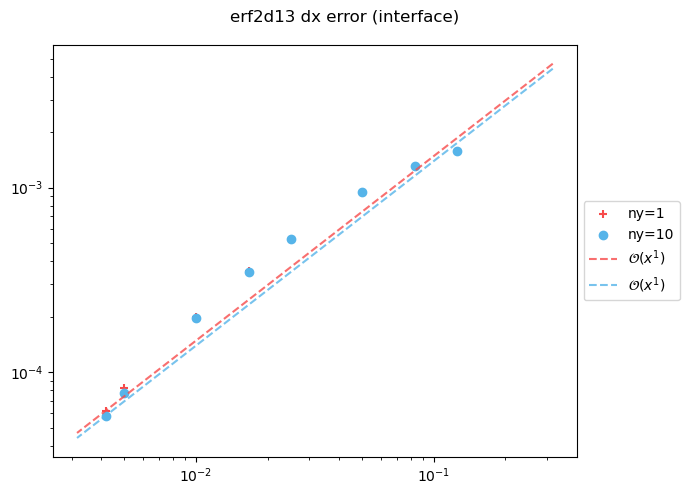

In [21]:
import numpy as np

fig, ax = plt.subplots(1, 1)

ax.set_yscale('log')
ax.set_xscale('log')

ax.scatter(vis1._pd['dx'], vis1._pd['interface_error'], label='ny=1', marker=vis1._markers[0])
ax.scatter(vis10._pd['dx'], vis10._pd['interface_error'], label='ny=10', marker=vis1._markers[1])

xs = np.logspace(-0.5, -2.5)

max_point = vis1._pd.loc[vis1._pd['interface_error'] == vis1._pd['interface_error'].min()]
ax.plot(xs, (xs / max_point['dx'].iloc[0]) ** 1 * max_point['interface_error'].iloc[0], label=r'$\mathcal{O}(x^1)$', linestyle='--', marker='', alpha=0.8)

max_point = vis10._pd.loc[vis10._pd['interface_error'] == vis10._pd['interface_error'].min()]
ax.plot(xs, (xs / max_point['dx'].iloc[0]) ** 1 * max_point['interface_error'].iloc[0], label=r'$\mathcal{O}(x^1)$', linestyle='--', marker='', alpha=0.8)

box=ax.get_position()
ax.legend(loc='center left', bbox_to_anchor=(1.0,0.5), ncol=1)
plt.tight_layout()

fig.suptitle('erf2d13 dx error (interface)')